# HW13: Токенизация, инференс и fine-tuning BERT-подобной модели

**Тема:** токенизация текста, инференс готовой BERT-подобной модели и базовый fine-tuning для классификации текста.

**Датасет:** `emotion` (классификация эмоций в текстах)

**Модель:** `distilbert-base-uncased`

## 2.3.1. Импорты, seed и среда

In [1]:
import os
os.environ["ACCELERATE_USE_CPU"] = "False" # Если GPU
# или наоборот "True", только CPU

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import torch
import os

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# ── Фиксируем seed ────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Определяем устройство ─────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

c:\Users\cucumber\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
PyTorch version: 2.5.1+cu121


## 2.3.2. Данные и первичный анализ

Датасет **`emotion`** содержит короткие твиты на английском языке, размечённые по 6 эмоциям:
`sadness`, `joy`, `love`, `anger`, `fear`, `surprise`.

Задача — многоклассовая классификация текста (6 классов).

In [3]:
# Загружаем датасет emotion
dataset = load_dataset("emotion")
print(dataset)

# Размеры split-частей
for split_name, split_data in dataset.items():
    print(f"{split_name}: {len(split_data)} примеров")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров


In [4]:
# Названия классов
label_names = dataset["train"].features["label"].names
print("Классы:", label_names)
num_labels = len(label_names)
print(f"Количество классов: {num_labels}")

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Количество классов: 6


In [5]:
# Sanity-check: несколько примеров текстов и меток
print("Примеры из train:")
for i in range(5):
    example = dataset["train"][i]
    label_str = label_names[example["label"]]
    print(f"  [{i}] label={label_str!r:10s} | text={example['text'][:80]!r}")

Примеры из train:
  [0] label='sadness'  | text='i didnt feel humiliated'
  [1] label='sadness'  | text='i can go from feeling so hopeless to so damned hopeful just from being around so'
  [2] label='anger'    | text='im grabbing a minute to post i feel greedy wrong'
  [3] label='love'     | text='i am ever feeling nostalgic about the fireplace i will know that it is still on '
  [4] label='anger'    | text='i am feeling grouchy'


In [6]:
# Распределение классов в train
train_df = pd.DataFrame(dataset["train"])
train_df["label_name"] = train_df["label"].map(lambda x: label_names[x])
print("Распределение классов (train):")
print(train_df["label_name"].value_counts())

Распределение классов (train):
label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


Датасет `emotion` уже содержит официальные сплиты `train / validation / test`.
Дополнительного разбиения не требуется.

## 2.3.3. Токенизация

In [7]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = [
    dataset["train"][0]["text"],
    dataset["train"][1]["text"],
    dataset["train"][2]["text"],
    dataset["train"][3]["text"],
    dataset["train"][4]["text"],
]

print("=" * 60)
print("Разбор токенизации для нескольких текстов")
print("=" * 60)

for i, text in enumerate(sample_texts):
    enc = tokenizer(text, truncation=True, padding=False)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    print(f"\n[{i}] Текст: {text[:60]!r}")
    print(f"  Токены       : {tokens}")
    print(f"  input_ids    : {enc['input_ids']}")
    print(f"  attention_mask: {enc['attention_mask']}")
    print(f"  Special tokens: [CLS]={tokens[0]!r}, [SEP]={tokens[-1]!r}")

Разбор токенизации для нескольких текстов

[0] Текст: 'i didnt feel humiliated'
  Токены       : ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
  input_ids    : [101, 1045, 2134, 2102, 2514, 26608, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1]
  Special tokens: [CLS]='[CLS]', [SEP]='[SEP]'

[1] Текст: 'i can go from feeling so hopeless to so damned hopeful just '
  Токены       : ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
  input_ids    : [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Special tokens: [CLS]='[CLS]', [SEP]='[SEP]'

[2] Текст: 'im grabbing a minute to post i feel greedy wrong'
  Токены       : ['[CLS]', 'im', 'grabbing', 'a', 'minute'

In [8]:
# Пример padding и truncation
batch = sample_texts[:3]
enc_padded = tokenizer(
    batch,
    truncation=True,
    padding=True,
    max_length=32,
    return_tensors="pt",
)
print("Пример padding (max_length=32):")
print("  input_ids shape     :", enc_padded["input_ids"].shape)
print("  attention_mask shape:", enc_padded["attention_mask"].shape)
for i in range(len(batch)):
    print(f"  [{i}] input_ids    : {enc_padded['input_ids'][i].tolist()}")
    print(f"  [{i}] attention_mask: {enc_padded['attention_mask'][i].tolist()}")

Пример padding (max_length=32):
  input_ids shape     : torch.Size([3, 23])
  attention_mask shape: torch.Size([3, 23])
  [0] input_ids    : [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  [0] attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  [1] input_ids    : [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
  [1] attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  [2] input_ids    : [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20505, 3308, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  [2] attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


**Вывод по токенизации:**
- Токенизатор DistilBERT добавляет специальные токены `[CLS]` (начало) и `[SEP]` (конец).
- `input_ids` — числовые идентификаторы токенов в словаре.
- `attention_mask` — маска: `1` для реальных токенов, `0` для паддинга.
- `padding=True` дополняет все последовательности в батче до одинаковой длины.
- `truncation=True` обрезает тексты, длиннее `max_length`.

## 2.3.4. Инференс готовой модели

In [9]:
# Используем готовую модель для классификации эмоций (trained на emotion dataset)
# distilbert-base-uncased-finetuned-sst-2-english — пример готовой BERT-подобной модели
# для sentiment analysis, чтобы показать, как такая модель работает "из коробки"
pretrained_pipeline = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if DEVICE == "cuda" else -1,
)

print("Инференс готовой pretrained модели (distilbert-base-uncased-finetuned-sst-2-english)")
print("Модель обучена на SST-2 (sentiment: POSITIVE / NEGATIVE)")
print("=" * 70)

inference_texts = [
    dataset["test"][0]["text"],
    dataset["test"][1]["text"],
    dataset["test"][2]["text"],
    dataset["test"][3]["text"],
    dataset["test"][4]["text"],
]
true_labels_sample = [
    label_names[dataset["test"][i]["label"]] for i in range(5)
]

results = pretrained_pipeline(inference_texts)

for text, true_lbl, res in zip(inference_texts, true_labels_sample, results):
    print(f"  Текст      : {text[:60]!r}")
    print(f"  Истинная метка (emotion): {true_lbl!r}")
    print(f"  Предсказание (SST-2)    : {res['label']!r}  (score={res['score']:.3f})")
    print()

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 12381.71it/s]


Инференс готовой pretrained модели (distilbert-base-uncased-finetuned-sst-2-english)
Модель обучена на SST-2 (sentiment: POSITIVE / NEGATIVE)
  Текст      : 'im feeling rather rotten so im not very ambitious right now'
  Истинная метка (emotion): 'sadness'
  Предсказание (SST-2)    : 'NEGATIVE'  (score=1.000)

  Текст      : 'im updating my blog because i feel shitty'
  Истинная метка (emotion): 'sadness'
  Предсказание (SST-2)    : 'NEGATIVE'  (score=0.999)

  Текст      : 'i never make her separate from me because i don t ever want '
  Истинная метка (emotion): 'sadness'
  Предсказание (SST-2)    : 'POSITIVE'  (score=0.999)

  Текст      : 'i left with my bouquet of red and yellow tulips under my arm'
  Истинная метка (emotion): 'joy'
  Предсказание (SST-2)    : 'POSITIVE'  (score=0.987)

  Текст      : 'i was feeling a little vain when i did this one'
  Истинная метка (emotion): 'sadness'
  Предсказание (SST-2)    : 'NEGATIVE'  (score=1.000)



In [10]:
print("""
Анализ соответствия готовой модели задаче:
─────────────────────────────────────────
Готовая модель distilbert-base-uncased-finetuned-sst-2-english обучена на
задаче sentiment analysis (2 класса: POSITIVE / NEGATIVE).

Наша задача — классификация 6 эмоций (sadness, joy, love, anger, fear, surprise).

Готовая модель НЕ подходит напрямую:
  - Не знает классов 'love', 'fear', 'surprise' и т.д.
  - Может частично коррелировать (joy → POSITIVE, anger/sadness → NEGATIVE),
    но точной классификации по 6 эмоциям не даёт.
  - Для корректного решения нужен fine-tuning на датасете emotion.
""")


Анализ соответствия готовой модели задаче:
─────────────────────────────────────────
Готовая модель distilbert-base-uncased-finetuned-sst-2-english обучена на
задаче sentiment analysis (2 класса: POSITIVE / NEGATIVE).

Наша задача — классификация 6 эмоций (sadness, joy, love, anger, fear, surprise).

Готовая модель НЕ подходит напрямую:
  - Не знает классов 'love', 'fear', 'surprise' и т.д.
  - Может частично коррелировать (joy → POSITIVE, anger/sadness → NEGATIVE),
    но точной классификации по 6 эмоциям не даёт.
  - Для корректного решения нужен fine-tuning на датасете emotion.



## 2.3.5. Fine-tuning для классификации текста

In [11]:
# Параметры
FT_MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 32
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
OUTPUT_DIR = "./ft_model"

# Токенизируем датасет
ft_tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_NAME)

def tokenize_fn(examples):
    return ft_tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_fn, batched=True)
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"],
)
print("Токенизация датасета завершена")
print(tokenized_dataset)

Токенизация датасета завершена
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [12]:
# Загружаем модель для sequence classification
ft_model = AutoModelForSequenceClassification.from_pretrained(
    FT_MODEL_NAME,
    num_labels=num_labels,
    id2label={i: label_names[i] for i in range(num_labels)},
    label2id={label_names[i]: i for i in range(num_labels)},
)
ft_model = ft_model.to(DEVICE)
print(f"Модель {FT_MODEL_NAME} загружена, num_labels={num_labels}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11096.34it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель distilbert-base-uncased загружена, num_labels=6


In [13]:

# Метрики для Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}


# Аргументы обучения
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=SEED,
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

print("Trainer инициализирован. Начинаем обучение...")

Trainer инициализирован. Начинаем обучение...


In [14]:
# Обучение
train_result = trainer.train()
print("Обучение завершено.")
print(f"Финальный train loss: {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.250276,0.219956,0.924000,0.897423
2,0.148595,0.164043,0.936500,0.908977
3,0.111036,0.154701,0.935000,0.908306


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.14it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Обучение завершено.
Финальный train loss: 0.2995


In [15]:
# История обучения для кривых
log_history = trainer.state.log_history

train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

print("Результаты по эпохам (validation):")
for ev in eval_logs:
    print(f"  epoch={ev.get('epoch'):.1f}  "
          f"eval_loss={ev.get('eval_loss', 0):.4f}  "
          f"accuracy={ev.get('eval_accuracy', 0):.4f}  "
          f"f1_macro={ev.get('eval_f1_macro', 0):.4f}")

Результаты по эпохам (validation):
  epoch=1.0  eval_loss=0.2200  accuracy=0.9240  f1_macro=0.8974
  epoch=2.0  eval_loss=0.1640  accuracy=0.9365  f1_macro=0.9090
  epoch=3.0  eval_loss=0.1547  accuracy=0.9350  f1_macro=0.9083


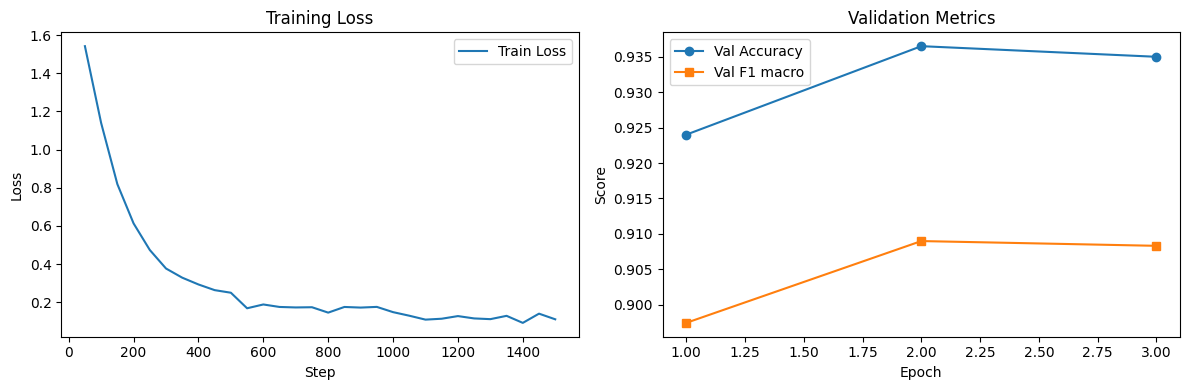

Сохранено: artifacts/training_curves.png


In [16]:
# Кривые обучения (опциональный артефакт)
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

if train_logs and eval_logs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Train loss
    train_steps = [x["step"] for x in train_logs]
    train_losses = [x["loss"] for x in train_logs]
    axes[0].plot(train_steps, train_losses, label="Train Loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training Loss")
    axes[0].legend()

    # Eval metrics
    eval_epochs = [x["epoch"] for x in eval_logs]
    eval_acc    = [x.get("eval_accuracy", 0) for x in eval_logs]
    eval_f1     = [x.get("eval_f1_macro", 0) for x in eval_logs]
    axes[1].plot(eval_epochs, eval_acc, marker="o", label="Val Accuracy")
    axes[1].plot(eval_epochs, eval_f1,  marker="s", label="Val F1 macro")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_title("Validation Metrics")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(ARTIFACTS_DIR, "training_curves.png"), dpi=100)
    plt.show()
    print("Сохранено: artifacts/training_curves.png")

## 2.3.6. Оценка качества и краткий анализ ошибок

Лучшая модель по `validation` выбрана через `load_best_model_at_end=True`.
Теперь проводим **финальную оценку на `test`** (один раз).

Запуск финальной оценки на TEST...

Итоговые метрики на TEST:
Accuracy: 0.9230
F1 macro: 0.8807
Артефакт сохранен: artifacts/sample_predictions.csv


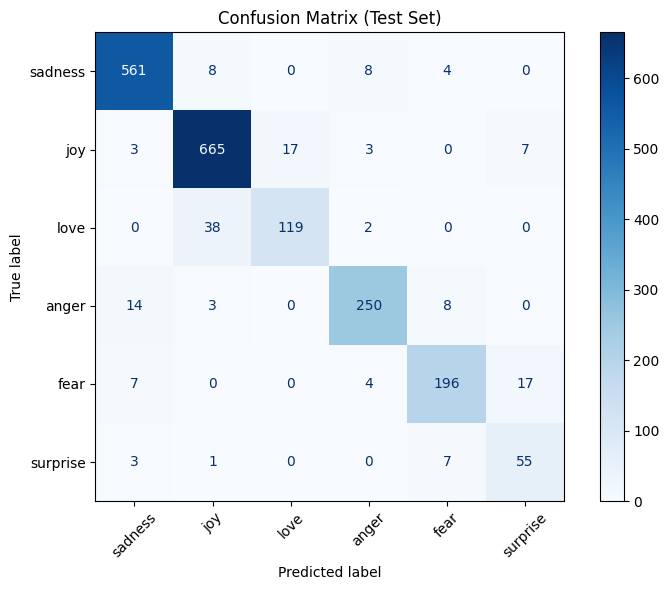

Артефакт сохранен: artifacts/confusion_matrix.png

Примеры ошибок (всего 154):
                                                                                                                                   text true_label pred_label
                                                                                                     i don t feel particularly agitated       fear      anger
i feel if i completely hated things i d exercise my democratic right speak my mind in what ever ways possible and try to enact a change      anger    sadness
                                                               i feel a bit stressed even though all the things i have going on are fun      anger    sadness
                                             i was feeling weird the other day and it went away about minutes after i took my metformin       fear   surprise
                                                                                              when a friend dropped a frog down my 

In [18]:
## 2.3.6. Оценка качества и краткий анализ ошибок

# Создаем папку для артефактов согласно структуре HW
ARTIFACTS_DIR = "artifacts" 
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Используем predict вместо evaluate, чтобы избежать ошибки жизненного цикла Trainer
print("Запуск финальной оценки на TEST...")
test_predictions = trainer.predict(tokenized_dataset["test"])
test_preds = np.argmax(test_predictions.predictions, axis=-1)
test_true  = test_predictions.label_ids

# Расчет метрик
acc = accuracy_score(test_true, test_preds)
f1  = f1_score(test_true, test_preds, average="macro")

print(f"\nИтоговые метрики на TEST:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 macro: {f1:.4f}")

# 1. Сохраняем sample_predictions.csv
test_texts = dataset["test"]["text"]
logits_tensor = torch.tensor(test_predictions.predictions)
probs = torch.softmax(logits_tensor, dim=-1).numpy()
confidence = probs[np.arange(len(test_preds)), test_preds]

pred_df = pd.DataFrame({
    "text": test_texts,
    "true_label": [label_names[i] for i in test_true],
    "pred_label": [label_names[i] for i in test_preds],
    "confidence": confidence.round(4)
})

pred_df.to_csv(os.path.join(ARTIFACTS_DIR, "sample_predictions.csv"), index=False)
print(f"Артефакт сохранен: {ARTIFACTS_DIR}/sample_predictions.csv")

# 2. Сохраняем confusion_matrix.png
cm = confusion_matrix(test_true, test_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "confusion_matrix.png"))
plt.show()
print(f"Артефакт сохранен: {ARTIFACTS_DIR}/confusion_matrix.png")

# Краткий анализ ошибок (обязательно по пункту 2.3.6)
errors_df = pred_df[pred_df["true_label"] != pred_df["pred_label"]]
print(f"\nПримеры ошибок (всего {len(errors_df)}):")
print(errors_df.head(5)[["text", "true_label", "pred_label"]].to_string(index=False))

In [19]:
# Получаем предсказания на test для матрицы ошибок и анализа
test_predictions = trainer.predict(tokenized_dataset["test"])
test_preds = np.argmax(test_predictions.predictions, axis=-1)
test_true  = test_predictions.label_ids

# Accuracy и F1 macro
acc = accuracy_score(test_true, test_preds)
f1  = f1_score(test_true, test_preds, average="macro")
print(f"Accuracy (test) : {acc:.4f}")
print(f"F1 macro (test) : {f1:.4f}")
print()
print("Classification report:")
print(classification_report(test_true, test_preds, target_names=label_names))

Accuracy (test) : 0.9230
F1 macro (test) : 0.8807

Classification report:
              precision    recall  f1-score   support

     sadness       0.95      0.97      0.96       581
         joy       0.93      0.96      0.94       695
        love       0.88      0.75      0.81       159
       anger       0.94      0.91      0.92       275
        fear       0.91      0.88      0.89       224
    surprise       0.70      0.83      0.76        66

    accuracy                           0.92      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.92      0.92      0.92      2000



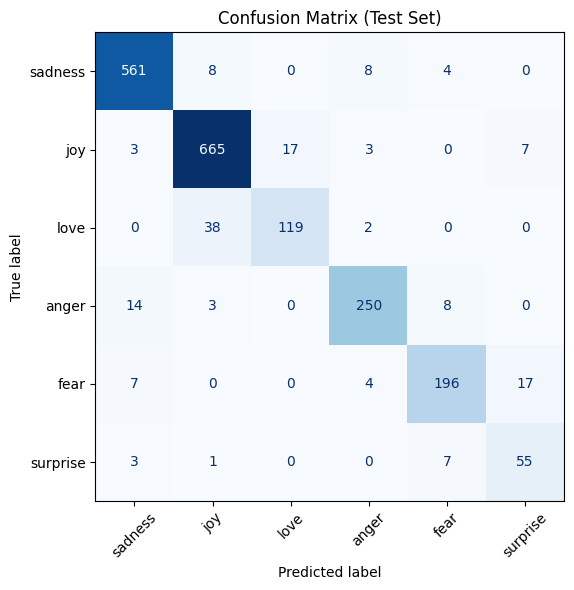

Сохранено: artifacts/confusion_matrix.png


In [20]:
# Матрица ошибок
cm = confusion_matrix(test_true, test_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "confusion_matrix.png"), dpi=100)
plt.show()
print("Сохранено: artifacts/confusion_matrix.png")

In [21]:
# Примеры предсказаний
test_texts = [dataset["test"][i]["text"] for i in range(len(dataset["test"]))]

# Уверенность (softmax)
logits_tensor = torch.tensor(test_predictions.predictions)
probs = torch.softmax(logits_tensor, dim=-1).numpy()
confidence = probs[np.arange(len(test_preds)), test_preds]

# Сохраняем sample_predictions.csv
pred_df = pd.DataFrame({
    "text"      : test_texts,
    "true_label": [label_names[i] for i in test_true],
    "pred_label": [label_names[i] for i in test_preds],
    "confidence": confidence.round(4),
})

pred_df.to_csv(os.path.join(ARTIFACTS_DIR, "sample_predictions.csv"), index=False)
print(f"Сохранено: artifacts/sample_predictions.csv  ({len(pred_df)} строк)")

# Показываем несколько примеров
print("\nПервые 10 предсказаний:")
print(pred_df.head(10).to_string(index=False))

Сохранено: artifacts/sample_predictions.csv  (2000 строк)

Первые 10 предсказаний:
                                                                                                                                                                                                                          text true_label pred_label  confidence
                                                                                                                                                                   im feeling rather rotten so im not very ambitious right now    sadness    sadness      0.9937
                                                                                                                                                                                     im updating my blog because i feel shitty    sadness    sadness      0.9954
                                                                                                                             i never make her sepa

In [22]:
# Анализ ошибок: смотрим на неправильные предсказания
errors_df = pred_df[pred_df["true_label"] != pred_df["pred_label"]].copy()
print(f"Всего ошибок: {len(errors_df)} из {len(pred_df)} примеров")
print(f"Error rate: {len(errors_df)/len(pred_df)*100:.1f}%")
print()
print("Примеры ошибок (первые 8):")
print(errors_df[["text", "true_label", "pred_label", "confidence"]].head(8).to_string(index=False))

Всего ошибок: 154 из 2000 примеров
Error rate: 7.7%

Примеры ошибок (первые 8):
                                                                                                                                                                                 text true_label pred_label  confidence
                                                                                                                                                   i don t feel particularly agitated       fear      anger      0.5606
                                              i feel if i completely hated things i d exercise my democratic right speak my mind in what ever ways possible and try to enact a change      anger    sadness      0.6295
                                                                                                             i feel a bit stressed even though all the things i have going on are fun      anger    sadness      0.4991
                                                        

In [23]:
# Наиболее частые пары (true → pred) ошибок
print("Топ-10 пар ошибок (true_label → pred_label):")
error_pairs = errors_df.groupby(["true_label", "pred_label"]).size().reset_index(name="count")
error_pairs = error_pairs.sort_values("count", ascending=False).head(10)
print(error_pairs.to_string(index=False))

print("""
Краткий комментарий по ошибкам:
───────────────────────────────
Наиболее частые ошибки происходят между близкими по тону эмоциями:
  • sadness ↔ fear  — оба класса описывают негативные ощущения;
  • joy ↔ love      — оба связаны с положительным настроением;
  • anger ↔ sadness — граница между гневом и грустью размыта в коротких твитах.

Пограничные случаи часто имеют низкий confidence (< 0.7), что говорит о
неуверенности модели там, где текст содержит смешанные сигналы.
""")

Топ-10 пар ошибок (true_label → pred_label):
true_label pred_label  count
      love        joy     38
      fear   surprise     17
       joy       love     17
     anger    sadness     14
   sadness      anger      8
     anger       fear      8
   sadness        joy      8
  surprise       fear      7
       joy   surprise      7
      fear    sadness      7

Краткий комментарий по ошибкам:
───────────────────────────────
Наиболее частые ошибки происходят между близкими по тону эмоциями:
  • sadness ↔ fear  — оба класса описывают негативные ощущения;
  • joy ↔ love      — оба связаны с положительным настроением;
  • anger ↔ sadness — граница между гневом и грустью размыта в коротких твитах.

Пограничные случаи часто имеют низкий confidence (< 0.7), что говорит о
неуверенности модели там, где текст содержит смешанные сигналы.

